# Playground

I always start by writting code to do quick checks, so this file will be a little bit messy... its not intended to be put at productio, not near close to it :P

In [22]:
from pathlib import Path
import pandas as pd
from collections import Counter
import json
from IPython.display import display

pd.set_option("display.float_format", "{:.1f}".format)

In [23]:
raw_data_customers_path = "../data/raw/customers.json"
raw_data_products_path = "../data/raw/products.csv"
raw_data_sales_path = "../data/raw/sales_data.json"

In [24]:
customers_df = pd.read_json(raw_data_customers_path)
products_df = pd.read_csv(raw_data_products_path)
#sales_df = pd.read_json(raw_data_sales_path) // Error, maybe be related to parsing

In [25]:
customers_df.head(5)

,CustomerID,Name,Region,SignUpDate,Email,LoyaltyPoints
0,8220,Brandon Bender,North,2023-08-14,mirandajoel@example.org,129
1,6670,Kari Ford,North,2020-03-02,brucewesley@example.org,528
2,9865,Andrea Leonard,NaN,2020-11-26,newmantimothy@example.com,2182
3,5082,Christina Mcdowell,NaN,2022-12-07,smithdouglas@example.com,3091
4,3737,Kevin Martin,South,2019-11-02,pinedakelli@example.net,1156


In [26]:
products_df.head(5)

,ProductID,ProductName,Category,Price,Supplier
0,207,,Puzzle,64,Brown-Garcia
1,732,Joseph,RC Toy,170,Ortiz Inc
2,463,Jacob,RC Toy,108,Hinton-Patterson
3,163,Shawn,Action Figure,107,"Rios, Cannon and Wheeler"
4,255,Daniel,Puzzle,163,Summers LLC


In [27]:
with open(raw_data_sales_path) as f:
    sales_raw_data = json.load(f)

print(type(sales_raw_data), len(sales_raw_data))
print(Counter(type(r).__name__ for r in sales_raw_data))

<class 'list'> 2983
Counter({'dict': 2895, 'str': 88})


In [28]:
bad = [(i, r) for i, r in enumerate(sales_raw_data) if not isinstance(r, dict)]
print(len(bad))
for i, r in bad[:5]:
    print(i, repr(r)[:200])

88
36 '{"SaleID": 423, "ProductID": 115, "CustomerID": 2318, "Quantity": 10, "TotalAmount": 910, "SaleDate": "2021-11-12"}'
120 '{"SaleID": 6461, "ProductID": 335, "CustomerID": 9926, "Quantity": 2, "TotalAmount": 24, "SaleDate": "2021-03-20"}'
185 '{"SaleID": 4264, "ProductID": 848, "CustomerID": 9898, "Quantity": 1, "TotalAmount": 174, "SaleDate": "2021-09-23"}'
228 '{"SaleID": 6742, "ProductID": 607, "CustomerID": 4756, "Quantity": 4, "TotalAmount": 732, "SaleDate": "2021-01-29"}'
311 '{"SaleID": 2730, "ProductID": 301, "CustomerID": 8124, "Quantity": 4, "TotalAmount": 736, "SaleDate": "2022-03-05"}'


88 elements are double serialized

In [29]:
records, malformed = [], []

for i, r in enumerate(sales_raw_data):
    if isinstance(r, dict):
        records.append(r)
    elif isinstance(r, str):
        try:
            records.append(json.loads(r))
        except json.JSONDecodeError:
            malformed.append((i, r))
    else:
        malformed.append((i, r))

sales_df = pd.json_normalize(records)

In [30]:
sales_df[sales_df.SaleID == 423] # There are elements in the json that contain other jsons... error that has to be solved

,SaleID,ProductID,CustomerID,Quantity,TotalAmount,SaleDate,find.SaleID,find.ProductID,find.CustomerID,find.Quantity,...,heavy.CustomerID,heavy.Quantity,heavy.TotalAmount,heavy.SaleDate,public.SaleID,public.ProductID,public.CustomerID,public.Quantity,public.TotalAmount,public.SaleDate
36,423.0,115.0,2318.0,10.0,910.0,2021-11-12,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
Counter(tuple(r) for r in sales_raw_data if isinstance(r, dict)) # 98 elements nested, generating malformed data.

Counter({('SaleID',
          'ProductID',
          'CustomerID',
          'Quantity',
          'TotalAmount',
          'SaleDate'): 2797,
         ('find',): 2,
         ('country',): 2,
         ('change',): 2,
         ('miss',): 1,
         ('ability',): 1,
         ('small',): 1,
         ('feeling',): 1,
         ('person',): 1,
         ('article',): 1,
         ('up',): 1,
         ('condition',): 1,
         ('bring',): 1,
         ('spend',): 1,
         ('course',): 1,
         ('simple',): 1,
         ('tonight',): 1,
         ('eat',): 1,
         ('member',): 1,
         ('standard',): 1,
         ('our',): 1,
         ('recently',): 1,
         ('attention',): 1,
         ('culture',): 1,
         ('summer',): 1,
         ('audience',): 1,
         ('seek',): 1,
         ('memory',): 1,
         ('from',): 1,
         ('keep',): 1,
         ('hair',): 1,
         ('response',): 1,
         ('daughter',): 1,
         ('civil',): 1,
         ('cause',): 1,
         ('m

In [32]:
sales_df.keys()

Index(['SaleID', 'ProductID', 'CustomerID', 'Quantity', 'TotalAmount',
       'SaleDate', 'find.SaleID', 'find.ProductID', 'find.CustomerID',
       'find.Quantity',
       ...
       'heavy.CustomerID', 'heavy.Quantity', 'heavy.TotalAmount',
       'heavy.SaleDate', 'public.SaleID', 'public.ProductID',
       'public.CustomerID', 'public.Quantity', 'public.TotalAmount',
       'public.SaleDate'],
      dtype='str', length=556)

In [33]:
records, malformed = [], []
for i, r in enumerate(sales_raw_data):
    if isinstance(r, str):
        try:
            r = json.loads(r)
        except json.JSONDecodeError:
            malformed.append((i, r)); continue

    if isinstance(r, dict):
        if len(r) == 1 and isinstance(next(iter(r.values())), dict):
            r = next(iter(r.values()))
        records.append(r)
    else:
        malformed.append((i, r))

sales_df = pd.DataFrame(records)

In [34]:
sales_df

,SaleID,ProductID,CustomerID,Quantity,TotalAmount,SaleDate,condition,standard,policy,example,a
0,5083.0,343.0,9320.0,9.0,1431.0,2023-06-19,NaN,NaN,NaN,NaN,NaN
1,6690.0,463.0,8458.0,6.0,648.0,2020-05-15,NaN,NaN,NaN,NaN,NaN
2,8362.0,750.0,8226.0,1.0,172.0,2022-11-03,NaN,NaN,NaN,NaN,NaN
3,6412.0,419.0,3217.0,9.0,1665.0,2023-06-17,NaN,NaN,NaN,NaN,NaN
4,1721.0,840.0,7811.0,8.0,800.0,2022-04-21,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2978,27.0,789.0,6886.0,9.0,612.0,2021-01-09,NaN,NaN,NaN,NaN,NaN
2979,3931.0,676.0,3284.0,1.0,62.0,2020-04-22,NaN,NaN,NaN,NaN,NaN
2980,9668.0,198.0,3064.0,2.0,28.0,2020-10-11,NaN,NaN,NaN,NaN,NaN
2981,1634.0,659.0,3116.0,7.0,413.0,2022-02-04,NaN,NaN,NaN,NaN,NaN


In [35]:
bronze = pd.DataFrame([
    {
        "_row_num": i,
        "_source_file": "sales_data.json",
        "_ingested_at": pd.Timestamp.utcnow(),
        "_payload": json.dumps(item, ensure_ascii=False),
    }
    for i, item in enumerate(sales_raw_data)
])

/tmp/ipykernel_27123/1119639899.py:5: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "_ingested_at": pd.Timestamp.utcnow(),


In [36]:
bronze

,_row_num,_source_file,_ingested_at,_payload
0,0,sales_data.json,2026-08-19 13:32:25.844040+00:00,"{""SaleID"": 5083, ""ProductID"": 343, ""CustomerID..."
1,1,sales_data.json,2026-08-19 13:32:25.844170+00:00,"{""SaleID"": 6690, ""ProductID"": 463, ""CustomerID..."
2,2,sales_data.json,2026-08-19 13:32:25.844216+00:00,"{""SaleID"": 8362, ""ProductID"": 750, ""CustomerID..."
3,3,sales_data.json,2026-08-19 13:32:25.844247+00:00,"{""SaleID"": 6412, ""ProductID"": 419, ""CustomerID..."
4,4,sales_data.json,2026-08-19 13:32:25.844275+00:00,"{""SaleID"": 1721, ""ProductID"": 840, ""CustomerID..."
...,...,...,...,...
2978,2978,sales_data.json,2026-08-19 13:32:25.916820+00:00,"{""SaleID"": 27, ""ProductID"": 789, ""CustomerID"":..."
2979,2979,sales_data.json,2026-08-19 13:32:25.916831+00:00,"{""SaleID"": 3931, ""ProductID"": 676, ""CustomerID..."
2980,2980,sales_data.json,2026-08-19 13:32:25.916841+00:00,"{""SaleID"": 9668, ""ProductID"": 198, ""CustomerID..."
2981,2981,sales_data.json,2026-08-19 13:32:25.916852+00:00,"{""SaleID"": 1634, ""ProductID"": 659, ""CustomerID..."


## Check products table

In [37]:
# Check products categories, duplicates, nulls

print("-------- NA values --------")
print(products_df.isna().sum(), "\n")

print("-------- Value counts ----------")
print(products_df.Category.value_counts(dropna=False), "\n")
# Action Figure is written in two different ways

print("-------- Duplicated ids --------")
print("Duplicated product ids:", products_df.ProductID.duplicated().sum(), "\n")
print(products_df[products_df.ProductID.duplicated(keep=False)], "\n")
# Product 254 is duplicated

print("-------- Empty product names --------")
print("Empty product names", (products_df.ProductName.str.strip() == "").sum(), "\n")


print("-------- Empty Supplier names --------")
print("Empty Supplier", (products_df["Supplier"].isna() | products_df["Supplier"].str.strip().eq("")).sum(), "\n")
print(products_df.Supplier.value_counts(dropna=False), "\n")

print("products_df.price.describe:", products_df.Price.describe(), "\n")

-------- NA values --------
ProductID      0
ProductName    0
Category       0
Price          0
Supplier       0
dtype: int64 

-------- Value counts ----------
Category
Puzzle           45
RC Toy           43
Action Figure    37
Doll             35
Board Game       26
Action-Figure    15
Name: count, dtype: int64 

-------- Duplicated ids --------
Duplicated product ids: 1 

     ProductID ProductName       Category  Price      Supplier
121        254              Action Figure    109  Price-Little
200        254              Action Figure    109  Price-Little 

-------- Empty product names --------
Empty product names 50 

-------- Empty Supplier names --------
Empty Supplier 0 

Supplier
Taylor Ltd                    2
Price-Little                  2
Brown-Garcia                  1
Ortiz Inc                     1
Hinton-Patterson              1
                             ..
Stanley-Ray                   1
Phillips-Roach                1
Duncan-Lewis                  1
Hill, Hughes

<Axes: title={'center': 'Raw categories'}, ylabel='Category'>

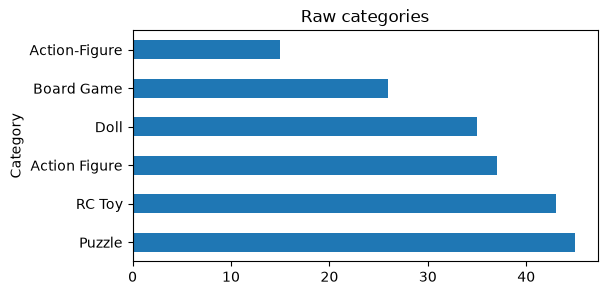

In [38]:
products_df.Category.value_counts().plot(kind="barh", figsize=(6,3), title="Raw categories")

## Check customers table

In [39]:
# customers: null check
print("customers_df len:", len(customers_df), "\n")
for c in customers_df.columns:
    print(c, customers_df[c].isna().sum(), customers_df[c].nunique())
print("\n", customers_df.Region.value_counts(dropna=False))

# 88 undefined Regions ~ 22% of data! -> Important
# 67 undefined SignUpDate ~ 19% of data! -> Important

customers_df len: 400 

CustomerID 0 400
Name 0 400
Region 88 4
SignUpDate 67 306
Email 0 400
LoyaltyPoints 0 382

 Region
North    91
NaN      88
West     76
South    75
East     70
Name: count, dtype: int64


<Axes: title={'center': 'Nulls per column - customers'}>

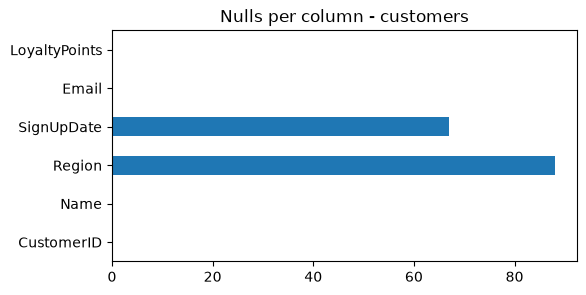

In [40]:
customers_df.isna().sum().plot(kind="barh", figsize=(6,3), title="Nulls per column - customers")

## Checks sales table

In [41]:
# sales: quick look

print("-------- Sales data description --------")
print(sales_df.describe(), "\n") # We can already tell that there is weird values like negative amounts and ids = 9999 | 99999 | 99998


print("-------- Sales.total_amount.describe --------")
print(sales_df.TotalAmount.describe(), "\n") # Nothing additional besides negative values.

print("-------- Sales.total_amount near zero values --------") # There are values near zero... this could be improved with business knowledge or with quantiles. 
print("Zero values:", (sales_df.TotalAmount <= 5.0).sum(), "\n")

print("-------- Sales.product_id checks --------")
print("Unique product ids:", sales_df.ProductID.nunique(), "\n")
print(f"Max Sale id: {sales_df.SaleID.max()}, Product id: {sales_df.ProductID.max()} and Customer id: {sales_df.CustomerID.max()}\n")   # 9999 / 99999 / 99989

print("-------- Null ids checks --------")
print(sales_df[["ProductID", "CustomerID", "SaleID"]].isna().sum(), f"from {len(sales_df)} elements. \n")

print("-------- dates --------")
print("Min/Max sale date: ", sales_df.SaleDate.min(), sales_df.SaleDate.max(), "\n") # Pivots

-------- Sales data description --------
       SaleID  ProductID  CustomerID  Quantity  TotalAmount
count  2978.0     2940.0      2978.0    2978.0       2978.0
mean   4958.9     2133.5      7280.4       5.6        589.9
std    2900.2    12612.7     12737.9       2.9        488.6
min       2.0      102.0      1063.0       1.0        -50.0
25%    2410.2      277.0      3292.0       3.0        180.0
50%    4910.5      512.0      5696.0       6.0        449.0
75%    7539.5      738.0      8064.0       8.0        894.0
max    9999.0    99999.0     99989.0      10.0       2000.0 

-------- Sales.total_amount.describe --------
count   2978.0
mean     589.9
std      488.6
min      -50.0
25%      180.0
50%      449.0
75%      894.0
max     2000.0
Name: TotalAmount, dtype: float64 

-------- Sales.total_amount near zero values --------
Zero values: 52 

-------- Sales.product_id checks --------
Unique product ids: 201 

Max Sale id: 9999.0, Product id: 99999.0 and Customer id: 99989.0

--------

<Axes: title={'center': 'Sales per month'}, xlabel='SaleDate'>

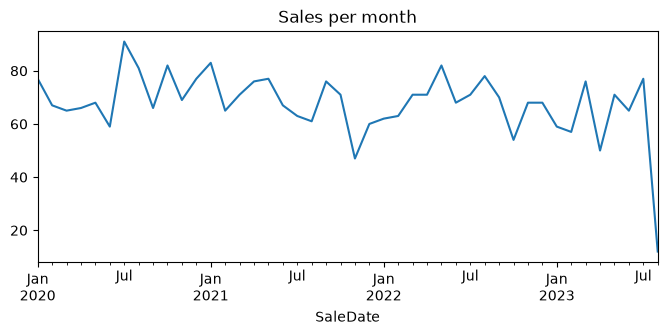

In [42]:
sales_df["SaleDate"] = pd.to_datetime(sales_df["SaleDate"])
sales_df.set_index("SaleDate").resample("ME").size().plot(kind="line", figsize=(8,3), title="Sales per month")

<Axes: title={'center': 'TotalAmount distribution'}, ylabel='Frequency'>

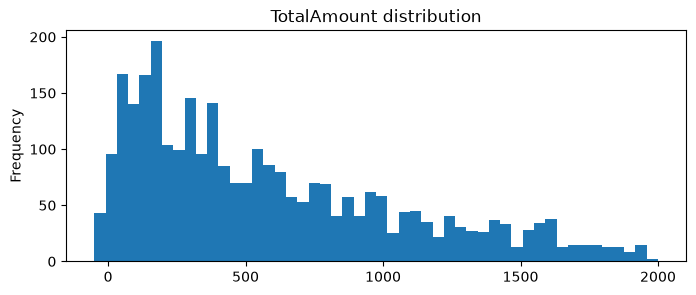

In [43]:
sales_df.TotalAmount.plot(kind="hist", bins=50, figsize=(8,3), title="TotalAmount distribution")

# Post bronze layer build

In [44]:
def display_parquets(dataset: str):
    layer = Path(f"../data/{dataset}/")

    for file in layer.glob("*.parquet"):
        print(f"\n------- {dataset + "." + file.name} -------")
        display(pd.read_parquet(file).head(3))

In [45]:
display_parquets("bronze")


------- bronze.quarantine.parquet -------


,batch_id,row_num,source,issue,detail,payload
0,20260817T190632Z,7,sales,wrapped_in_key,find,"{""find"": {""SaleID"": 4762, ""ProductID"": 343, ""C..."
1,20260817T190632Z,36,sales,double_serialised,NaN,"""{\""SaleID\"": 423, \""ProductID\"": 115, \""Custo..."
2,20260817T190632Z,99,sales,wrapped_in_key,miss,"{""miss"": {""SaleID"": 6606, ""ProductID"": 954, ""C..."



------- bronze.products.parquet -------


,ProductID,ProductName,Category,Price,Supplier,_batch_id,_row_num,_source_file,_ingested_at,_decoded
0,207,,Puzzle,64,Brown-Garcia,20260817T190632Z,0,products.csv,2026-08-17 19:06:32.075085+00:00,True
1,732,Joseph,RC Toy,170,Ortiz Inc,20260817T190632Z,1,products.csv,2026-08-17 19:06:32.075085+00:00,True
2,463,Jacob,RC Toy,108,Hinton-Patterson,20260817T190632Z,2,products.csv,2026-08-17 19:06:32.075085+00:00,True



------- bronze.customers.parquet -------


,CustomerID,Name,Region,SignUpDate,Email,LoyaltyPoints,_batch_id,_row_num,_source_file,_ingested_at,_decoded
0,8220,Brandon Bender,North,2023-08-14,mirandajoel@example.org,129,20260817T190632Z,0,customers.json,2026-08-17 19:06:32.064955+00:00,True
1,6670,Kari Ford,North,2020-03-02,brucewesley@example.org,528,20260817T190632Z,1,customers.json,2026-08-17 19:06:32.064955+00:00,True
2,9865,Andrea Leonard,NaN,2020-11-26,newmantimothy@example.com,2182,20260817T190632Z,2,customers.json,2026-08-17 19:06:32.064955+00:00,True



------- bronze.sales.parquet -------


,SaleID,ProductID,CustomerID,Quantity,TotalAmount,SaleDate,_batch_id,_row_num,_source_file,_ingested_at,_decoded
0,5083,343,9320,9,1431,2023-06-19,20260817T190632Z,0,sales_data.json,2026-08-17 19:06:32.023058+00:00,True
1,6690,463,8458,6,648,2020-05-15,20260817T190632Z,1,sales_data.json,2026-08-17 19:06:32.023058+00:00,True
2,8362,750,8226,1,172,2022-11-03,20260817T190632Z,2,sales_data.json,2026-08-17 19:06:32.023058+00:00,True


# Post Silver layer build

In [46]:
display_parquets("silver")


------- silver.products.parquet -------


,product_id,product_name,category,price,supplier,_batch_id,_row_num,_source_file,_ingested_at
0,207,NaN,puzzle,64,Brown-Garcia,20260817T190632Z,0,products.csv,2026-08-17 19:06:32.075085+00:00
1,732,Joseph,rc toy,170,Ortiz Inc,20260817T190632Z,1,products.csv,2026-08-17 19:06:32.075085+00:00
2,463,Jacob,rc toy,108,Hinton-Patterson,20260817T190632Z,2,products.csv,2026-08-17 19:06:32.075085+00:00



------- silver.customers.parquet -------


,customer_id,name,region,signup_date,email,loyalty_points,_batch_id,_row_num,_source_file,_ingested_at
0,8220,Brandon Bender,North,2023-08-14,mirandajoel@example.org,129,20260817T190632Z,0,customers.json,2026-08-17 19:06:32.064955+00:00
1,6670,Kari Ford,North,2020-03-02,brucewesley@example.org,528,20260817T190632Z,1,customers.json,2026-08-17 19:06:32.064955+00:00
2,9865,Andrea Leonard,NaN,2020-11-26,newmantimothy@example.com,2182,20260817T190632Z,2,customers.json,2026-08-17 19:06:32.064955+00:00



------- silver.sales.parquet -------


,sale_id,product_id,customer_id,quantity,total_amount,sale_date,_batch_id,_row_num,_source_file,_ingested_at,has_product,has_customer,amount_is_valid
0,5083,343,9320,9,1431,2023-06-19,20260817T190632Z,0,sales_data.json,2026-08-17 19:06:32.023058+00:00,True,True,True
1,6690,463,8458,6,648,2020-05-15,20260817T190632Z,1,sales_data.json,2026-08-17 19:06:32.023058+00:00,True,True,True
2,8362,750,8226,1,172,2022-11-03,20260817T190632Z,2,sales_data.json,2026-08-17 19:06:32.023058+00:00,True,True,True


# Post Gold layer build

In [47]:
display_parquets("gold")


------- gold.dim_products.parquet -------


,product_id,product_name,category,price,supplier
0,207,NaN,puzzle,64,Brown-Garcia
1,732,Joseph,rc toy,170,Ortiz Inc
2,463,Jacob,rc toy,108,Hinton-Patterson



------- gold.fct_sales.parquet -------


,sale_id,product_id,customer_id,quantity,total_amount,sale_date,has_product,has_customer,amount_is_valid,category,price,region,signup_date,after_signup,unit_price
0,5083,343,9320,9,1431,2023-06-19,True,True,True,doll,159.0,NaN,2021-11-08,True,159.0
1,6690,463,8458,6,648,2020-05-15,True,True,True,rc toy,108.0,South,2022-09-01,False,108.0
2,8362,750,8226,1,172,2022-11-03,True,True,True,action figure,172.0,West,2023-10-16,False,172.0



------- gold.dim_customers.parquet -------


,customer_id,name,region,signup_date,email,loyalty_points
0,8220,Brandon Bender,North,2023-08-14,mirandajoel@example.org,129
1,6670,Kari Ford,North,2020-03-02,brucewesley@example.org,528
2,9865,Andrea Leonard,NaN,2020-11-26,newmantimothy@example.com,2182
